# COLX 531 Lab 2. Training transformers efficiently

You can find a list of techniques to optimize training efficiency [here](https://huggingface.co/docs/transformers/perf_train_gpu_one). Please make extensive use of the public documentation to understand what this notebook does.

### Objective

1. Understanding the trade-off between different training optimization techniques.
2. Apply various optimization techniques to speed up training or reduce memory usage.

Instructions:
1. Register for an account on [Weights & Biases](https://wandb.ai/site);
2. Run the training code below. You are asked to log the whole training process with W&B. Each run takes less than 2 hours. Please do not change the code except for a few lines.
3. When you submit, **please also submit a pdf version of your notebook**.
4. This assignment requires the use of a GPU. Theoretically, it could be completed with the free tier of Colab.

### Assignment 1.1
rubric={accuracy:15}

During model training, sync training statistics to your Weights & Biases page under your own account. Please paste the link to your W&B page to all your models. You should use **COLX531** as the project name and **lab2_adam** / **lab2_efficient** / **lab2_8bit_adam** as the run names for these models respectively. They must be separate runs of the same project.

**Note**. you must make this W&B page public. Ohterwise we cannot grade your answer. If we cannot access your W&B page during grading, we will assign 0 to this question. However, you can also submit a screenshot of your W&B page. But your username **must** be included in the screenshot.

1. **lab2_adam**  
Train a machine translation model using the original code. Use the 32-bit adam optimizer and an effective batch size of 128 (hint: use gradient accumulation).
2. **lab2_efficient**   
Keep all hyperparameters of **lab2_adam** except for the following settings. Apply gradient checkpointing and mixed-precision training (fp16 or bf16).
Adjust your batch size and gradient accumulation of fit the released memory. But you must keep an effective batch size of 128.
3. **lab2_8bit_adam**   
Keep all hyperparameters of **lab2_efficient** except for the following settings. Use 8-bit adam optimizer as your optimizer. Adjust your batch size and gradient accumulation of fit the released memory. Adjust your batch size and gradient accumulation of fit the released memory. But you must keep an effective batch size of 128. You are expected to install `bitsandbytes` to use the 8-bit adam optimizer.

### Assignment 1.2
rubric={accuracy:20}

Please answer the following questions **in your own words**. Ansers that are copied from existing sources without paraphrasing will not be graded.




1. What is gradient checkpointing? What does it do?
2. What is a learning rate scheduler? What is warm-up? Why are they helpful?
3. Compare lab2_adam / lab2_efficient / lab2_8bit_adam and discuss how different techniques save memory and enable faster training. (Please inspect your w&b page before answering this question. Hint: Check out the `Process GPU Memory Allocated (%)` panel).
4. Are there any differences between the 32-bit adam optimizer and the 8-bit adam optimizer in terms of loss/bleu/training speed? (Please inspect your w&b page before answering this question).

my w&b page link: https://wandb.ai/yuchenli-cn-university-of-british-columbia/COLX531_lab2?nw=nwuseryuchenlicn


1. What is gradient checkpointing? What does it do?

Gradient checkpoint is a memory-saving technique by reducing the GPU memory use during the training.

Normally, deep models store all intermediate activations for backpropagation.

But with gradient checkpointing, only a subset of activations is stored while others are recomputed when needed.

2. What is a learning rate scheduler? What is warm-up? Why are they helpful?

A learning rate scheduler adjusts the learning rate dynamically during training instead of keeping it constant. It will be efficient for convergence.

Warm-up is a technique where the learning rate starts small and gradually increases at the beginning of training. It can be stable at early training.

3. Compare lab2_adam / lab2_efficient / lab2_8bit_adam and discuss how different techniques save memory and enable faster training. (Please inspect your w&b page before answering this question. Hint: Check out the Process GPU Memory Allocated (%) panel).

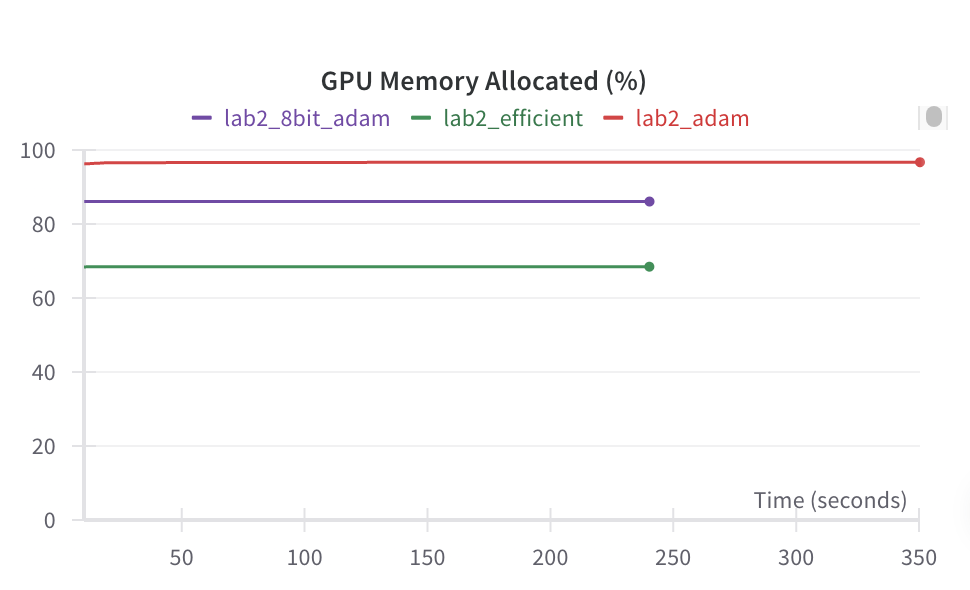





| Method              | BLEU Score | Training Loss | Speed (samples/s) | GPU Usage |
|---------------------|-----------|--------------|-------------------|-----------|
| lab2_adam          | 43.24     | 1.5541       | 68.60             | ~100%     |
| lab2_efficient     | 44.34     | 1.3942       | 154.88            | ~65%      |
| lab2_8bit_adam     | 44.83     | 1.3072       | 159.45            | ~85%      |

8-bit Adam achieves the best BLEU score and the lowest training loss, indicating better performance. It also has the fastest training speed, slightly surpassing the efficient method. In terms of memory usage, gradient checkpointing reduces GPU memory usage the most (\~35% lower than Adam), while 8-bit Adam still offers a moderate reduction (\~15% lower than Adam) while maintaining high speed.

4. Are there any differences between the 32-bit adam optimizer and the 8-bit adam optimizer in terms of loss/bleu/training speed? (Please inspect your w&b page before answering this question).

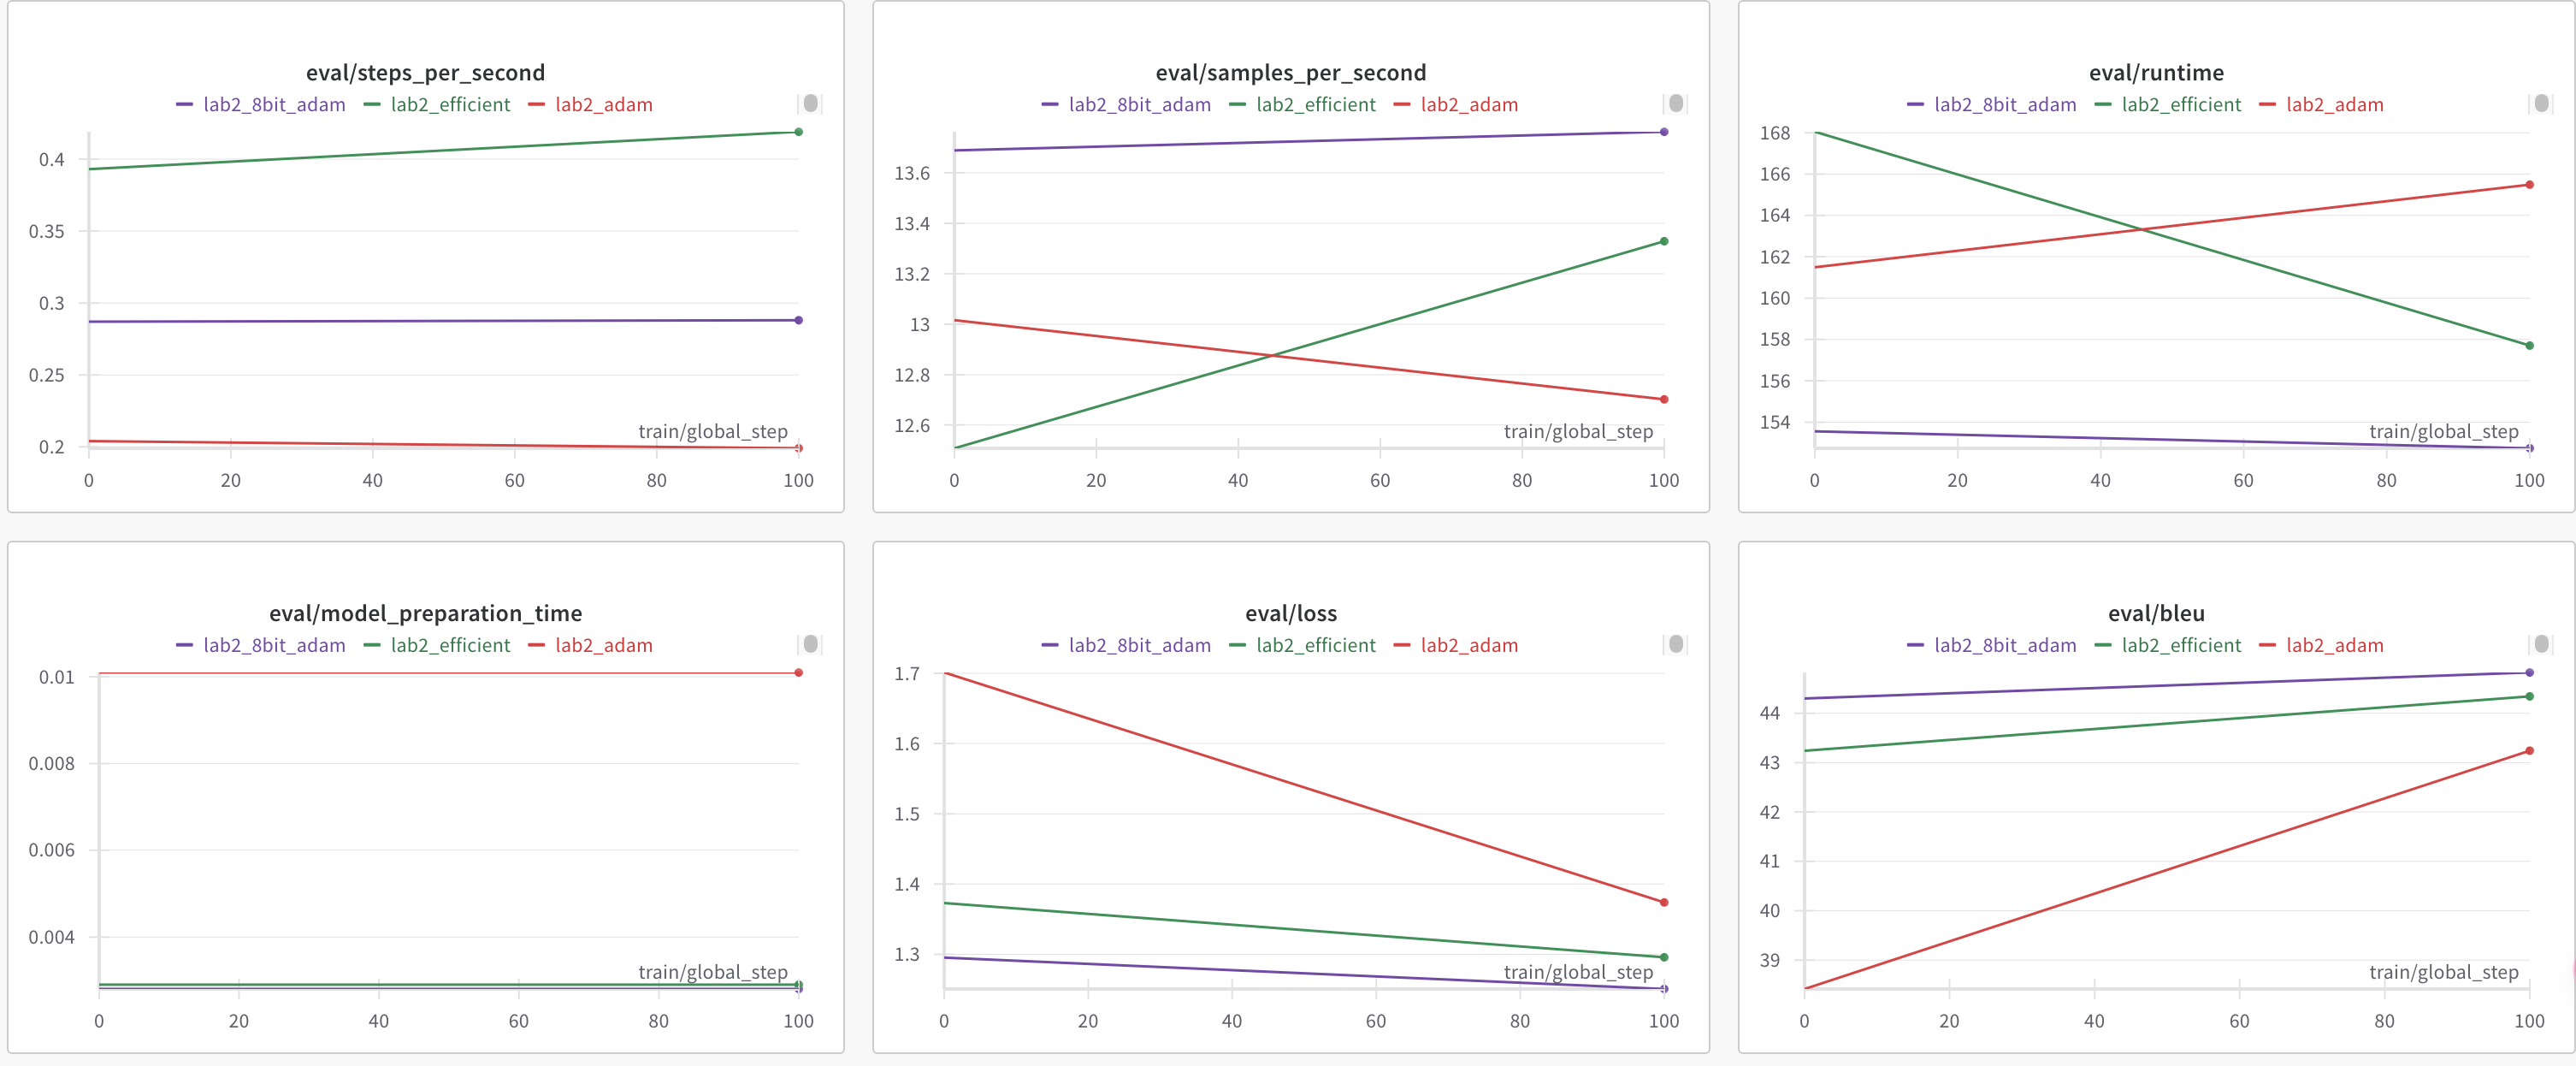
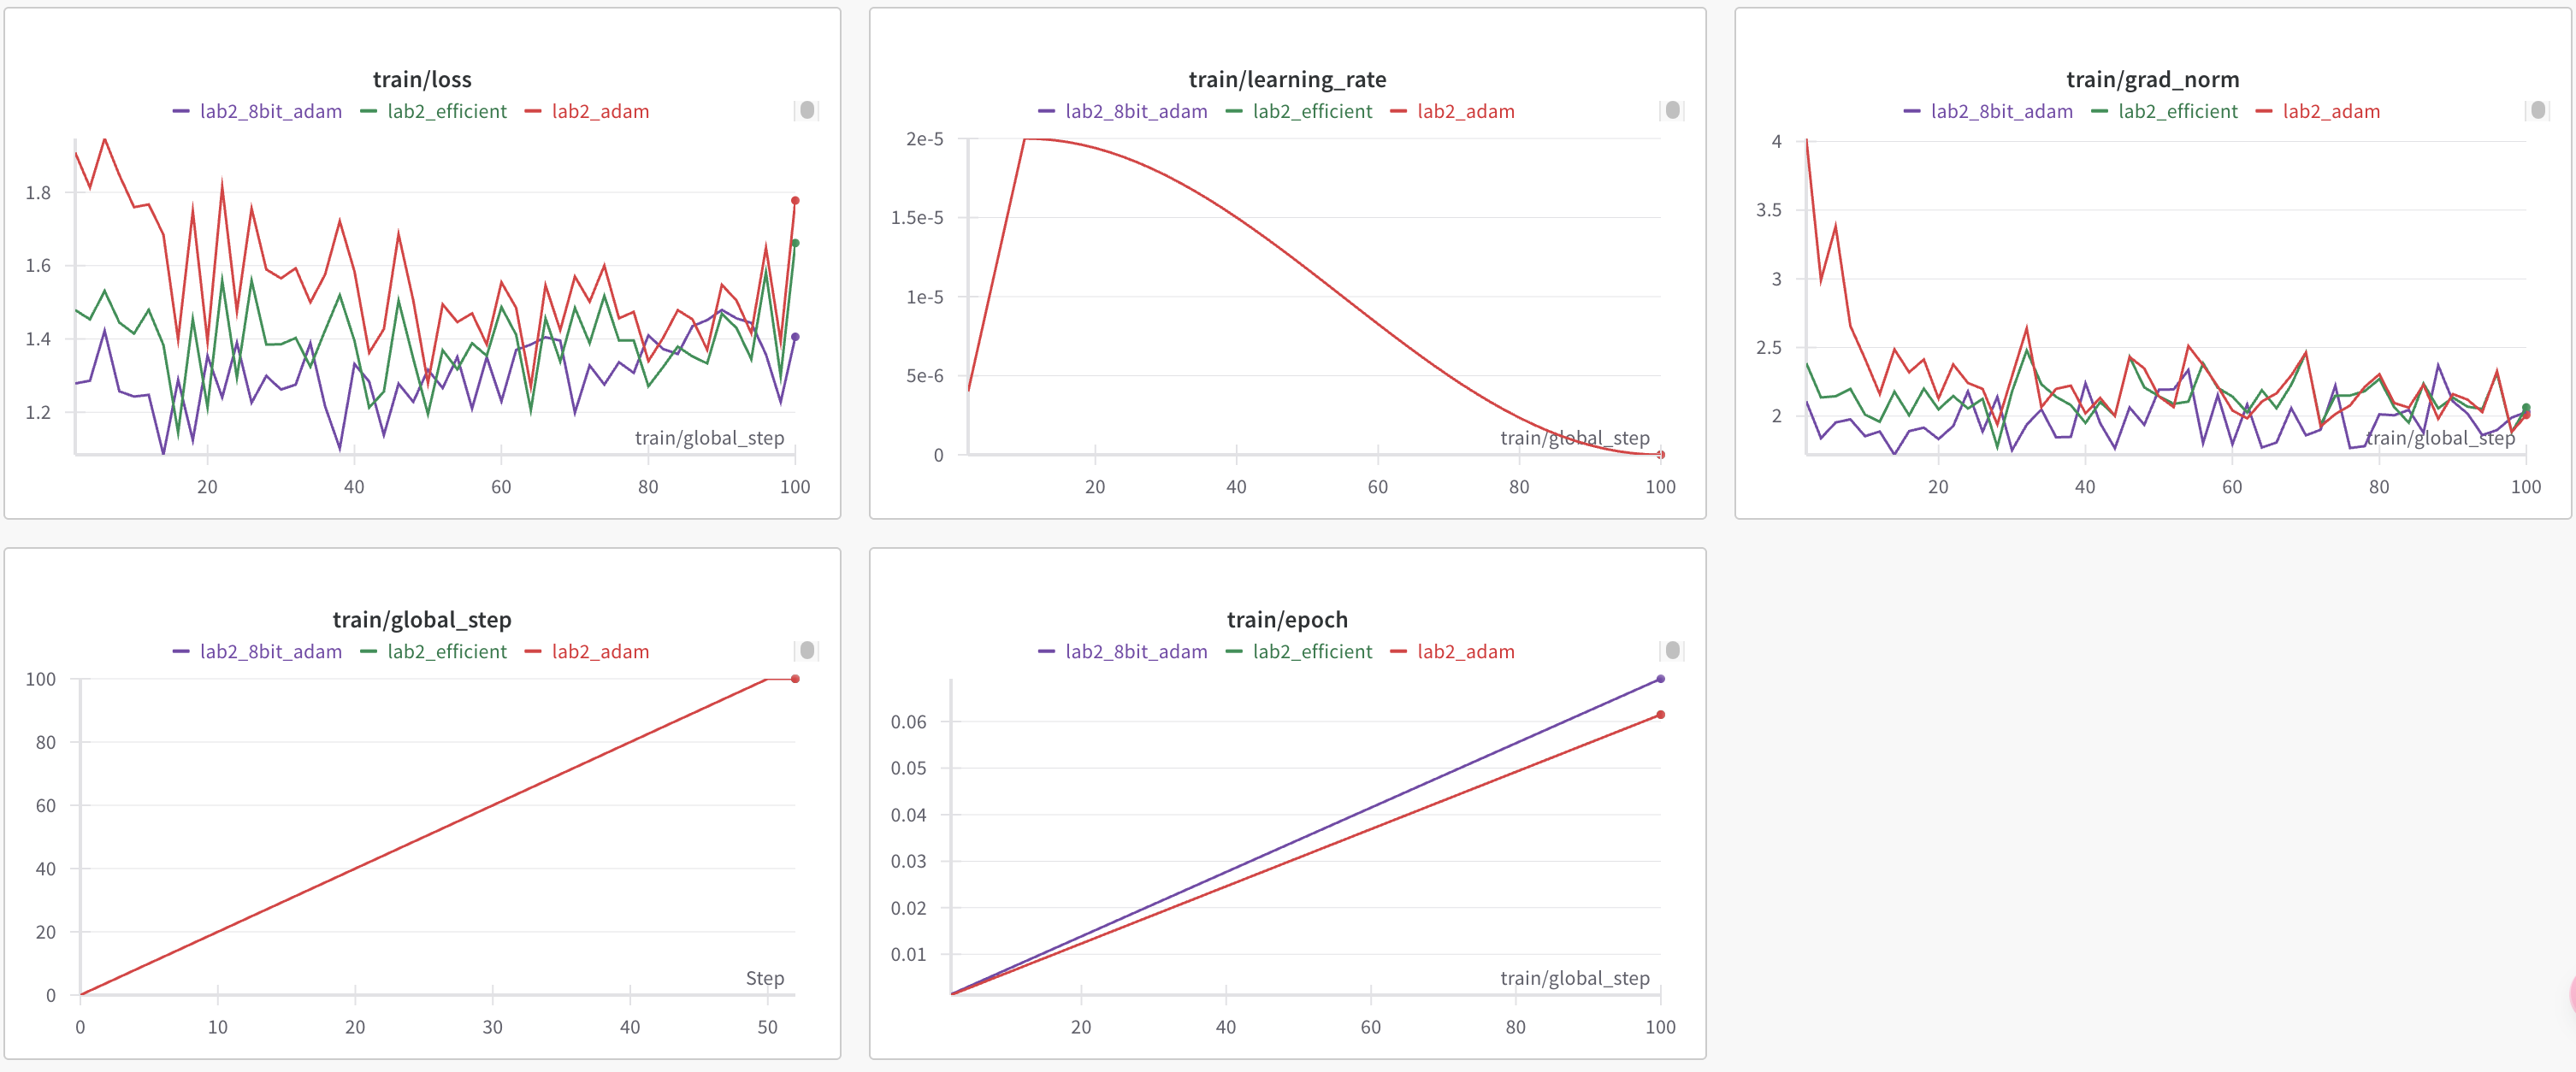
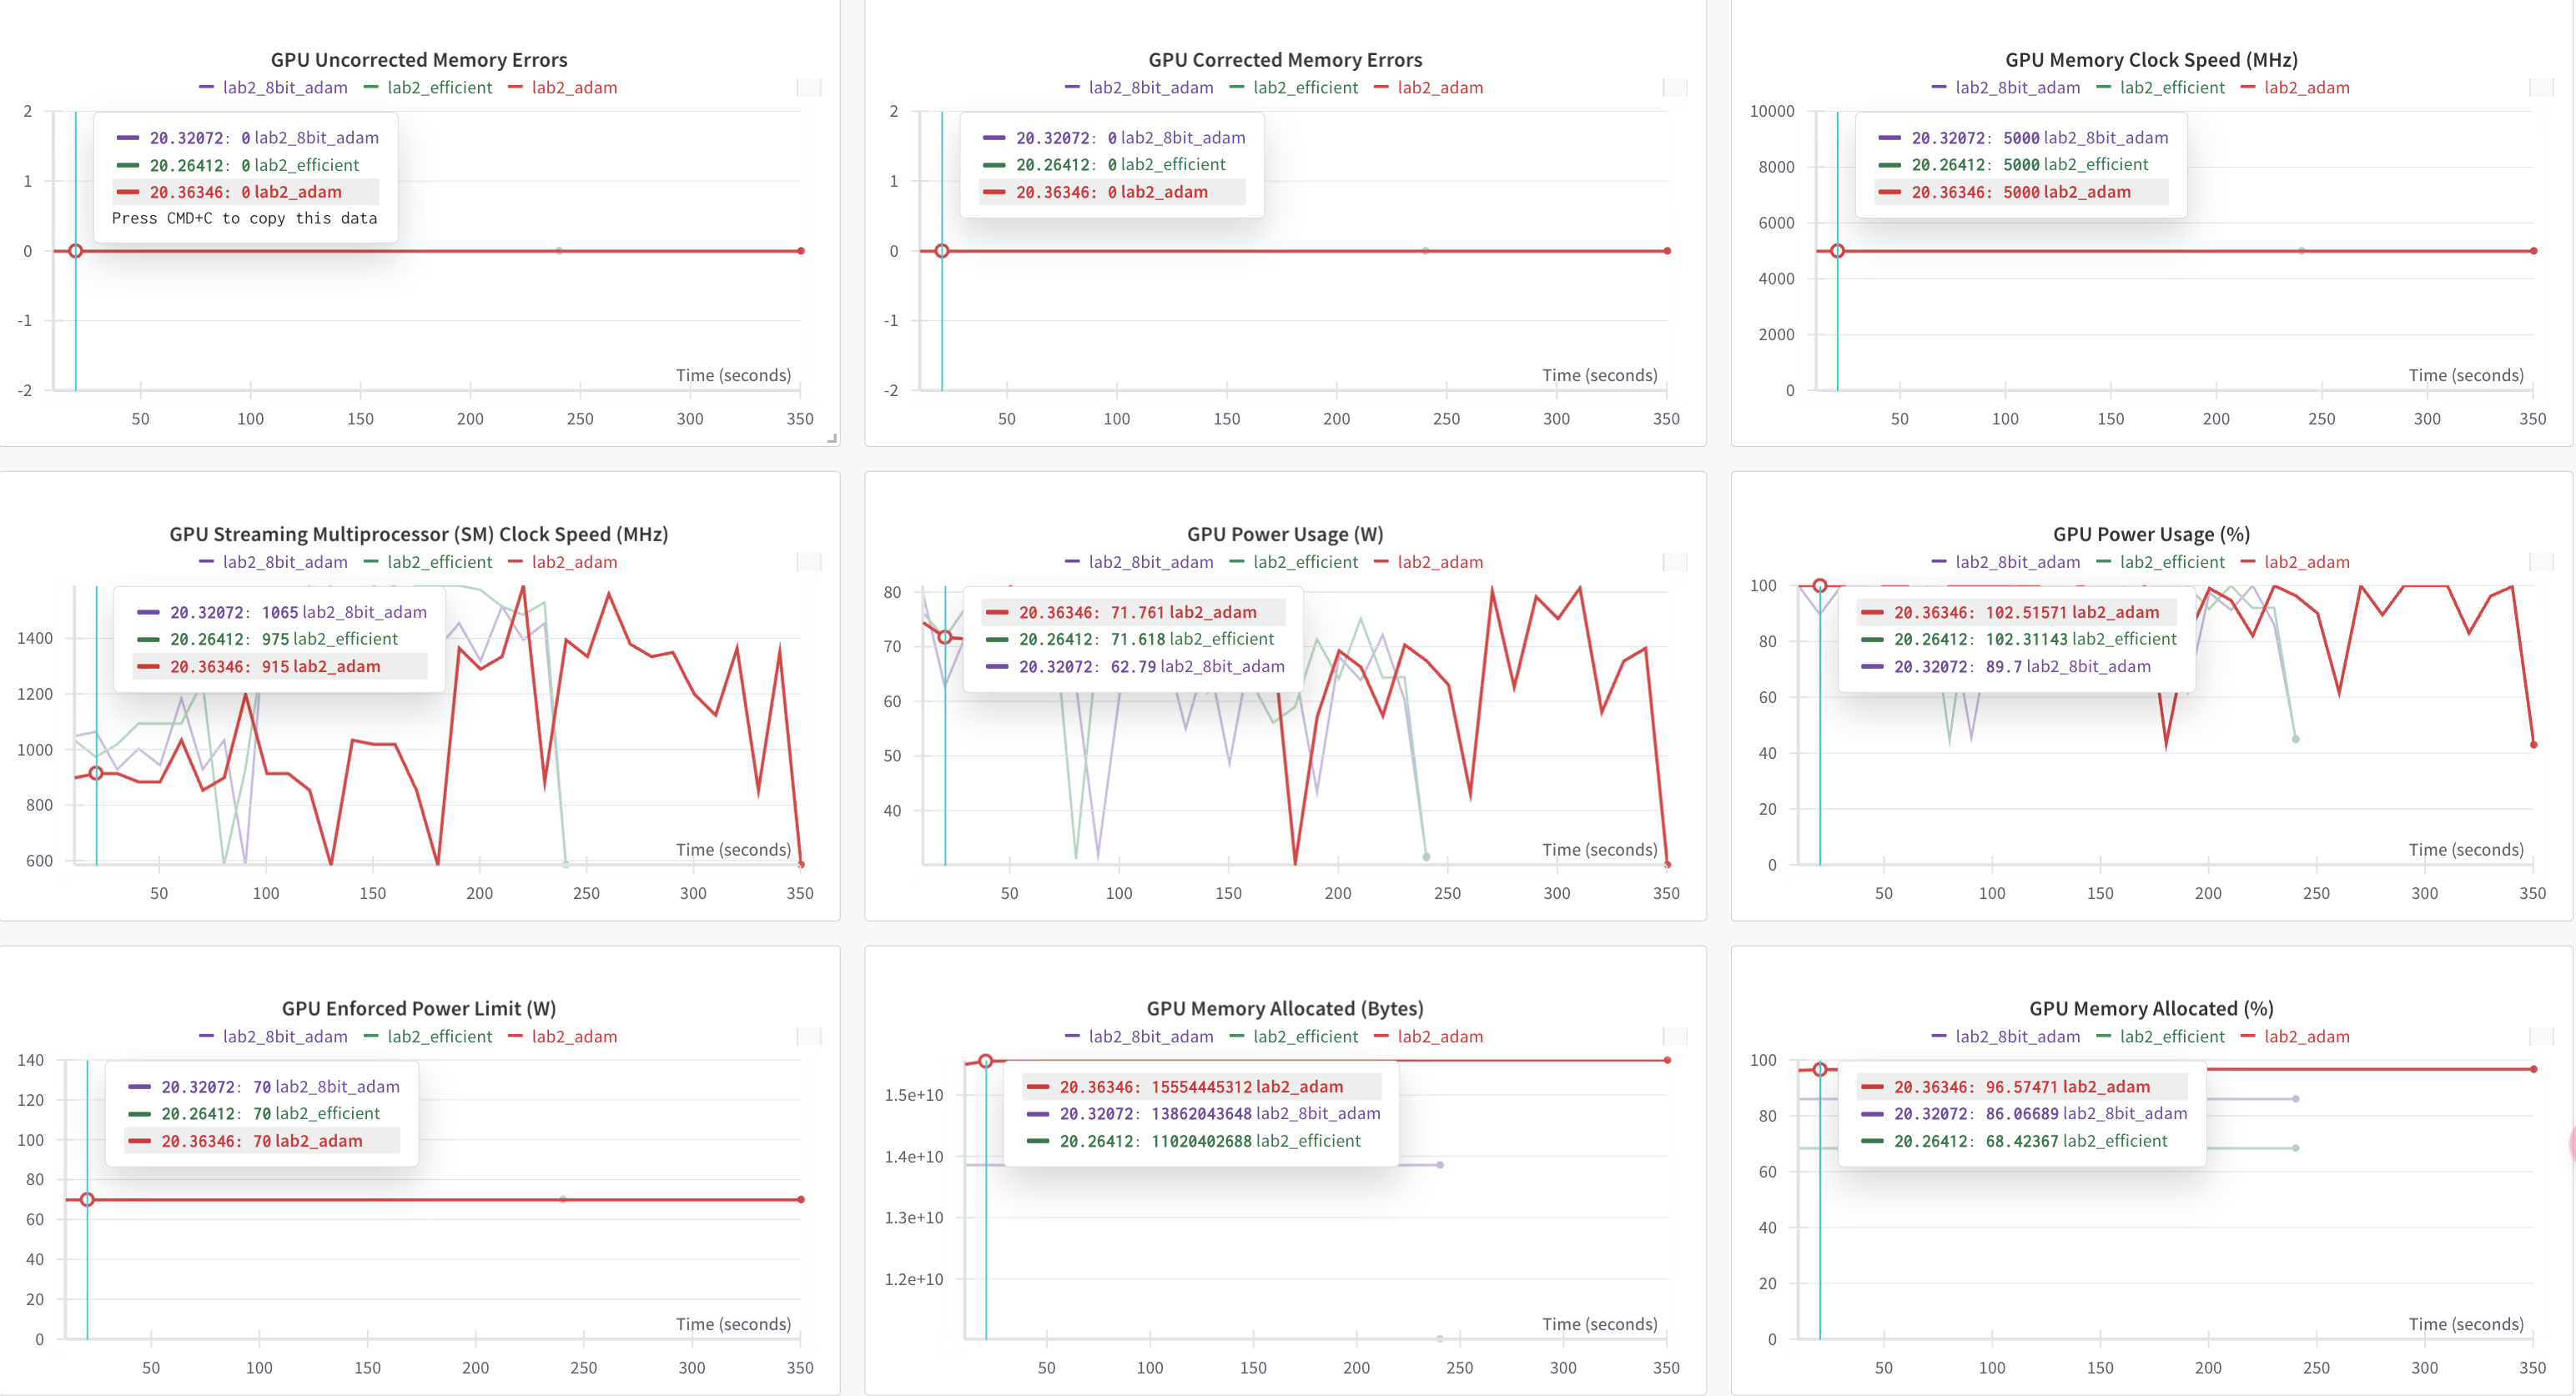
    
| Metric              | 32-bit Adam (lab2_adam) | 8-bit Adam (lab2_8bit_adam) | Difference |
|---------------------|----------------------|----------------------|------------|
| BLEU Score         | 43.24                | 44.83                | +1.59      |
| Training Loss      | 1.5541               | 1.3072               | Lower      |
| Training Speed (samples/s) | 68.60        | 159.45               | 2.3x faster |
| Memory Usage       | High                 | Lower                | Optimized  |

8-bit Adam achieves a **higher BLEU score**, indicating better translation quality. It also results in a **lower training loss**, suggesting improved convergence. Additionally, **training speed is more than twice as fast**, making it a more efficient choice. In terms of memory usage, 8-bit Adam significantly reduces the optimizer state size, leading to **better GPU efficiency**.  

Overall, **8-bit Adam outperforms 32-bit Adam in all aspects**, making it the preferred choice unless numerical precision is a concern.

Install the wandb, Transformers, Datasets, and Evaluate libraries to run this notebook.

In [5]:
# Install the wandb, Transformers, Datasets, and Evaluate libraries  (your comment should look like this)
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate bitsandbytes
!pip install wandb
# To run the training on TPU, you will need to uncomment the following line:
# !pip install cloud-tpu-client==0.10 torch==1.9.0 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.9-cp37-cp37m-linux_x86_64.whl
!apt install git-lfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

You will need to setup git, adapt your email and name in the following cell.

You will also need to be logged in to the Hugging Face Hub. Execute the following and enter your credentials.

In [3]:
# log in to your own wandb account
import wandb
wandb.login(key='ba52643060539d94db14aa8699f1e9d0631e4a9a')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yuchenli-cn (yuchenli-cn-university-of-british-columbia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# load dataset
from datasets import load_dataset

raw_datasets = load_dataset("kde4", lang1="en", lang2="fr")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.10k [00:00<?, ?B/s]

kde4.py:   0%|          | 0.00/4.25k [00:00<?, ?B/s]

The repository for kde4 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/kde4.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/210173 [00:00<?, ? examples/s]

In [7]:
#split the dataset into train and test
split_datasets = raw_datasets["train"].train_test_split(train_size=0.99, seed=20)
split_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 208071
    })
    test: Dataset({
        features: ['id', 'translation'],
        num_rows: 2102
    })
})

In [8]:
# rename the "test" dataset to "validation"
split_datasets["validation"] = split_datasets.pop("test")

In [9]:
from transformers import pipeline
# "Helsinki-NLP/opus-mt-en-fr" is a pre-trained MarianMT model that translates English (en) to French (fr).
model_checkpoint = "Helsinki-NLP/opus-mt-en-fr"
# Initializes a translation pipeline using the specified model.
translator = pipeline("translation", model=model_checkpoint)
translator("Default to expanded threads")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

...

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda:0


[{'translation_text': 'Par défaut pour les threads élargis'}]

In [10]:
from transformers import AutoTokenizer
# Specify the pre-trained model checkpoint (this one is for English-to-French translation)
model_checkpoint = "Helsinki-NLP/opus-mt-en-fr"

# Load the corresponding tokenizer, which converts text into a format that the model can process
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, return_tensors="pt")

In [11]:
# Retrieve an English sentence from the training set
en_sentence = split_datasets["train"][1]["translation"]["en"]

# Retrieve the corresponding French translation from the training set
fr_sentence = split_datasets["train"][1]["translation"]["fr"]

# Tokenize the English sentence as input and the French sentence as the target output
inputs = tokenizer(en_sentence, text_target=fr_sentence)

# Display the tokenized input-output pair
inputs

{'input_ids': [12406, 4, 1129, 7, 4, 4808, 2075, 37, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [40276, 19, 689, 5, 8, 6897, 5, 8, 2075, 402, 38492, 0]}

In [12]:
max_length = 128  # Maximum sequence length for tokenization

def preprocess_function(examples):
    """
    Preprocesses the input examples for translation.

    Args:
        examples (dict): A dictionary containing a batch of examples with "translation" key,
                         where each entry has "en" (English text) and "fr" (French text).

    Returns:
        dict: Tokenized inputs and target sequences.
    """
    # Extract English (source) and French (target) texts from the dataset
    inputs = [ex["en"] for ex in examples["translation"]]
    targets = [ex["fr"] for ex in examples["translation"]]

    # Tokenize the input and target texts with truncation
    model_inputs = tokenizer(
        inputs, text_target=targets, max_length=max_length, truncation=True
    )

    return model_inputs


In [13]:
tokenized_datasets = split_datasets.map(
    preprocess_function,  # Apply the preprocessing function to each dataset split
    batched=True,  # Process multiple examples at once for efficiency
    remove_columns=split_datasets["train"].column_names,  # Remove original columns after tokenization
)


Map:   0%|          | 0/208071 [00:00<?, ? examples/s]

Map:   0%|          | 0/2102 [00:00<?, ? examples/s]

In [14]:
from transformers import AutoModelForSeq2SeqLM

# Load the pretrained sequence-to-sequence model from the specified checkpoint
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

In [15]:
from transformers import DataCollatorForSeq2Seq

# Create a data collator to dynamically pad sequences during batching
# This ensures that all sequences in a batch have the same length without unnecessary padding beforehand
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [16]:
# Create a batch of tokenized examples using the data collator
# This dynamically pads sequences to the same length within the batch
batch = data_collator([tokenized_datasets["train"][i] for i in range(1, 3)])

# Display the keys of the resulting batch (e.g., input_ids, attention_mask, labels)
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'decoder_input_ids'])

In [17]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.1 MB/s eta 0:00:00


In [18]:
import evaluate

# Load the SacreBLEU metric for evaluating translation quality
metric = evaluate.load("sacrebleu")

In [19]:
import numpy as np

def compute_metrics(eval_preds):
    """
    Compute BLEU score for model evaluation.

    Args:
        eval_preds (tuple): A tuple containing model predictions and labels.

    Returns:
        dict: A dictionary with the BLEU score.
    """
    preds, labels = eval_preds

    # If the model returns additional outputs, extract the predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    # Decode predicted token IDs into text
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Replace -100s in labels (used for ignored tokens) with the padding token ID
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode label token IDs into text
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Remove extra whitespace from predictions and labels
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]  # BLEU expects list of references

    # Compute BLEU score using the SacreBLEU metric
    result = metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {"bleu": result["score"]}

# lab2_adam

In [20]:
from transformers import Seq2SeqTrainingArguments
import os

# Set the Weights & Biases project name for logging
os.environ["WANDB_PROJECT"] = "COLX531_lab2"

# Define training arguments for the sequence-to-sequence model
args = Seq2SeqTrainingArguments(
    f"marian-finetuned-kde4-en-to-fr",  # Directory name for saving the trained model
    eval_strategy="no",  # No evaluation during training
    save_strategy="epoch",  # Save the model at the end of each epoch
    learning_rate=2e-5,  # Learning rate for the optimizer
    per_device_train_batch_size=64,  # Batch size per device during training
    per_device_eval_batch_size=64,  # Batch size per device during evaluation
    gradient_accumulation_steps=2,  # Accumulate gradients over multiple steps to simulate a larger batch size
    weight_decay=0.1,  # Weight decay for regularization
    max_grad_norm=1.0,  # Gradient clipping to prevent exploding gradients
    lr_scheduler_type="cosine",  # Use a cosine learning rate scheduler
    warmup_ratio=0.1,  # Proportion of training steps for learning rate warmup
    save_total_limit=3,  # Keep only the last 3 saved models
    max_steps=100,  # Train for only 100 steps
    predict_with_generate=True,  # Enable text generation for evaluation
    report_to="wandb",  # Log training progress to Weights & Biases
    run_name="lab2_adam",  # Experiment name for tracking different runs
    logging_steps=2,  # Log training progress every 2 steps
    optim="adamw_torch_fused",  # Use PyTorch's fused AdamW optimizer (32-bit)
)

In [21]:
from transformers import Seq2SeqTrainer
import torch

# Initialize the Seq2SeqTrainer for training and evaluation
trainer = Seq2SeqTrainer(
    model=model,  # The pre-trained sequence-to-sequence model
    args=args,  # Training arguments defined earlier
    train_dataset=tokenized_datasets["train"],  # Training dataset
    eval_dataset=tokenized_datasets["validation"],  # Validation dataset for evaluation
    data_collator=data_collator,  # Data collator for dynamic padding
    tokenizer=tokenizer,  # Tokenizer for processing text
    compute_metrics=compute_metrics,  # Function to compute evaluation metrics (BLEU)
)

<ipython-input-21-c32959c16b23>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [22]:
# Evaluate the model on the validation dataset
# max_length specifies the maximum sequence length for generated predictions
trainer.evaluate(max_length=max_length)

{'eval_loss': 1.7011359930038452,
 'eval_model_preparation_time': 0.0101,
 'eval_bleu': 38.41300494663786,
 'eval_runtime': 161.4921,
 'eval_samples_per_second': 13.016,
 'eval_steps_per_second': 0.204}

In [23]:
# Start training the model using the specified training arguments and dataset
trainer.train()

Step,Training Loss
2,1.908100
4,1.813300
6,1.946900
8,1.847100
10,1.759500
12,1.766900
14,1.684500
16,1.398500
18,1.748300
20,1.392800


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:2758: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[59513]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=100, training_loss=1.5541312742233275, metrics={'train_runtime': 186.5994, 'train_samples_per_second': 68.596, 'train_steps_per_second': 0.536, 'total_flos': 303712400572416.0, 'train_loss': 1.5541312742233275, 'epoch': 0.06150061500615006})

In [24]:
# Evaluate the model on the validation dataset after training
# max_length specifies the maximum sequence length for generated predictions
trainer.evaluate(max_length=max_length)

{'eval_loss': 1.3738259077072144,
 'eval_model_preparation_time': 0.0101,
 'eval_bleu': 43.24239593300917,
 'eval_runtime': 165.4884,
 'eval_samples_per_second': 12.702,
 'eval_steps_per_second': 0.199,
 'epoch': 0.06150061500615006}

In [25]:
wandb.finish()

eval/bleu,▁█
eval/loss,█▁
eval/model_preparation_time,▁▁
eval/runtime,▁█
eval/samples_per_second,█▁
eval/steps_per_second,█▁
train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,█▅▆▃▃▃▂▂▃▂▁▂▃▁▂▁▂▁▃▂▁▃▂▂▁▂▂▂▃▁▂▂▂▁▂▂▂▁▂▁
train/learning_rate,▂▄▅▇██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/loss,█▇█▇▆▅▂▆▂▇▆▄▄▄▃▆▄▂▅▃▃▃▃▂▄▁▄▃▄▃▃▃▂▃▃▄▃▃▅▆


# lab2_efficient

In [26]:
from transformers import Seq2SeqTrainingArguments
import os

# Set the project name for Weights & Biases logging
os.environ["WANDB_PROJECT"] = "COLX531_lab2"

# Define training arguments for the Seq2Seq model
args = Seq2SeqTrainingArguments(
    f"marian-finetuned-kde4-en-to-fr",  # Output directory for the model
    eval_strategy="no",  # No evaluation during training
    save_strategy="epoch",  # Save model at the end of each epoch
    learning_rate=2e-5,  # Learning rate for the optimizer
    per_device_train_batch_size=32,  # Reduced batch size per device to fit memory
    per_device_eval_batch_size=32,  # Reduced evaluation batch size per device
    gradient_accumulation_steps=4,  # Increase accumulation steps to maintain an effective batch size of 128
    weight_decay=0.1,  # Weight decay for regularization
    max_grad_norm=1.0,  # Gradient clipping to prevent exploding gradients
    lr_scheduler_type="cosine",  # Use a cosine learning rate scheduler
    warmup_ratio=0.1,  # Warmup steps as a fraction of total training steps
    save_total_limit=3,  # Keep only the last 3 saved models
    max_steps=100,  # Train for only 100 steps
    predict_with_generate=True,  # Enable text generation for evaluation
    report_to="wandb",  # Log training progress to Weights & Biases
    run_name="lab2_efficient",  # Experiment name for tracking
    logging_steps=2,  # Log every 2 steps
    optim="adamw_torch_fused",  # Use PyTorch fused AdamW optimizer (32-bit)
    gradient_checkpointing=True,  # Enable gradient checkpointing to save memory
    fp16=True,  # Enable mixed-precision training with FP16
)


In [27]:
from transformers import Seq2SeqTrainer
import torch

# Initialize the Seq2SeqTrainer for training and evaluation
trainer = Seq2SeqTrainer(
    model=model,  # The pre-trained sequence-to-sequence model
    args=args,  # Training arguments defined earlier
    train_dataset=tokenized_datasets["train"],  # Training dataset
    eval_dataset=tokenized_datasets["validation"],  # Validation dataset for evaluation
    data_collator=data_collator,  # Data collator for dynamic padding
    tokenizer=tokenizer,  # Tokenizer for processing text
    compute_metrics=compute_metrics,  # Function to compute evaluation metrics (BLEU)
)

<ipython-input-27-c32959c16b23>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [28]:
# Evaluate the model on the validation dataset
# max_length specifies the maximum sequence length for generated predictions
trainer.evaluate(max_length=max_length)

{'eval_loss': 1.3729585409164429,
 'eval_model_preparation_time': 0.0029,
 'eval_bleu': 43.240395230190664,
 'eval_runtime': 168.0474,
 'eval_samples_per_second': 12.508,
 'eval_steps_per_second': 0.393}

In [29]:
# Start training the model using the specified training arguments and dataset
trainer.train()

Step,Training Loss
2,1.478700
4,1.453300
6,1.530700
8,1.444700
10,1.414500
12,1.479300
14,1.383400
16,1.144700
18,1.454500
20,1.213800


TrainOutput(global_step=100, training_loss=1.3941830921173095, metrics={'train_runtime': 82.6467, 'train_samples_per_second': 154.876, 'train_steps_per_second': 1.21, 'total_flos': 243847888109568.0, 'train_loss': 1.3941830921173095, 'epoch': 0.06151007227433492})

In [30]:
# Evaluate the model on the validation dataset after training
# max_length specifies the maximum sequence length for generated predictions
trainer.evaluate(max_length=max_length)

{'eval_loss': 1.2957433462142944,
 'eval_model_preparation_time': 0.0029,
 'eval_bleu': 44.34277291413853,
 'eval_runtime': 157.7035,
 'eval_samples_per_second': 13.329,
 'eval_steps_per_second': 0.419,
 'epoch': 0.06151007227433492}

In [31]:
wandb.finish()

eval/bleu,▁█
eval/loss,█▁
eval/model_preparation_time,▁▁
eval/runtime,█▁
eval/samples_per_second,▁█
eval/steps_per_second,▁█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
train/grad_norm,▇▅▅▅▃▅▃▅▄▅▄▁▅█▆▄▃▄▃█▅▄▄▅▅▅▄▅█▃▅▆▄▃▆▅▄▄▆▄
train/learning_rate,▂▄▅▇██████▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/loss,▆▅▆▅▅▄▁▂▇▃▄▄▃▅▆▂▃▆▄▂▃▄▄▆▅▅▄▆▄▆▄▃▃▄▄▅▅▄▇█


# lab2_8bit_adam

In [32]:
from transformers import Seq2SeqTrainingArguments
import os

# Set the project name for Weights & Biases logging
os.environ["WANDB_PROJECT"] = "COLX531_lab2"

# Define training arguments for the Seq2Seq model
args = Seq2SeqTrainingArguments(
    f"marian-finetuned-kde4-en-to-fr",  # Output directory for the model
    eval_strategy="no",  # No evaluation during training
    save_strategy="epoch",  # Save model at the end of each epoch
    learning_rate=2e-5,  # Learning rate for the optimizer
    per_device_train_batch_size=48,  # Increase batch size per device to utilize freed memory
    per_device_eval_batch_size=48,  # Adjust evaluation batch size accordingly
    gradient_accumulation_steps=3,  # Reduce accumulation steps to maintain an effective batch size of 128
    weight_decay=0.1,  # Weight decay for regularization
    max_grad_norm=1.0,  # Gradient clipping to prevent exploding gradients
    lr_scheduler_type="cosine",  # Use a cosine learning rate scheduler
    warmup_ratio=0.1,  # Warmup steps as a fraction of total training steps
    save_total_limit=3,  # Keep only the last 3 saved models
    max_steps=100,  # Train for only 100 steps
    predict_with_generate=True,  # Enable text generation for evaluation
    report_to="wandb",  # Log training progress to Weights & Biases
    run_name="lab2_8bit_adam",  # Experiment name for tracking
    logging_steps=2,  # Log every 2 steps
    optim="adamw_8bit",  # Use 8-bit Adam optimizer from bitsandbytes
    gradient_checkpointing=True,  # Enable gradient checkpointing to save memory
    fp16=True,  # Enable mixed-precision training with FP16
)

In [33]:
from transformers import Seq2SeqTrainer
import torch

# Initialize the Seq2SeqTrainer for training and evaluation
trainer = Seq2SeqTrainer(
    model=model,  # The pre-trained sequence-to-sequence model
    args=args,  # Training arguments defined earlier
    train_dataset=tokenized_datasets["train"],  # Training dataset
    eval_dataset=tokenized_datasets["validation"],  # Validation dataset for evaluation
    data_collator=data_collator,  # Data collator for dynamic padding
    tokenizer=tokenizer,  # Tokenizer for processing text
    compute_metrics=compute_metrics,  # Function to compute evaluation metrics (BLEU)
)

<ipython-input-33-c32959c16b23>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [34]:
# Evaluate the model on the validation dataset
# max_length specifies the maximum sequence length for generated predictions
trainer.evaluate(max_length=max_length)

{'eval_loss': 1.2952913045883179,
 'eval_model_preparation_time': 0.0028,
 'eval_bleu': 44.29981348597364,
 'eval_runtime': 153.5537,
 'eval_samples_per_second': 13.689,
 'eval_steps_per_second': 0.287}

In [35]:
# Start training the model using the specified training arguments and dataset
trainer.train()

Step,Training Loss
2,1.278400
4,1.285900
6,1.422100
8,1.257000
10,1.242700
12,1.247300
14,1.083800
16,1.288400
18,1.123700
20,1.353800


TrainOutput(global_step=100, training_loss=1.3071859073638916, metrics={'train_runtime': 90.3135, 'train_samples_per_second': 159.445, 'train_steps_per_second': 1.107, 'total_flos': 316309880438784.0, 'train_loss': 1.3071859073638916, 'epoch': 0.06920415224913495})

In [36]:
# Evaluate the model on the validation dataset after training
# max_length specifies the maximum sequence length for generated predictions
trainer.evaluate(max_length=max_length)

{'eval_loss': 1.2506107091903687,
 'eval_model_preparation_time': 0.0028,
 'eval_bleu': 44.82751008018826,
 'eval_runtime': 152.7335,
 'eval_samples_per_second': 13.763,
 'eval_steps_per_second': 0.288,
 'epoch': 0.06920415224913495}

In [37]:
wandb.finish()

eval/bleu,▁█
eval/loss,█▁
eval/model_preparation_time,▁▁
eval/runtime,█▁
eval/samples_per_second,▁█
eval/steps_per_second,▁█
train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▅▂▄▄▃▁▃▃▂▃▃▆▁▃▅▂▇▄▂▅▆▆█▂▂▂▂▅▃▃▂▄▄▅▃▅▄▃▃▅
train/learning_rate,▂▄▅▇██████▇▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train/loss,▄▅▇▄▄▁▅▂▆▄▄▅▄▄▆▁▅▅▂▄▄▆▃▆▄▆▇▇▃▅▅▅▇▆▆██▇▆▇
